In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready")



Environment ready


# Trader Behavior vs Market Sentiment

## Objective
The objective of this analysis is to explore the relationship between
Bitcoin market sentiment (Fear & Greed Index) and trader performance,
with a focus on profitability, risk-taking, and trading behavior.


In [13]:
trades = pd.read_csv("/content/historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)


Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [14]:
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Dataset Description

The trader dataset contains execution-level trading records including
trade direction, position size, execution price, fees, and realized PnL.

The sentiment dataset provides daily Bitcoin market sentiment using the
Fear & Greed Index, which categorizes market conditions such as Fear
and Greed.


In [17]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format="%d-%m-%Y %H:%M"
)
trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


In [18]:
sentiment['sentiment_group'] = sentiment['classification'].replace({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})


In [19]:
merged = pd.merge(
    trades,
    sentiment[['date', 'sentiment_group', 'value']],
    on='date',
    how='left'
)


In [20]:
merged['sentiment_group'].value_counts(dropna=False)


,count
sentiment_group,
Greed,90295
Fear,83237
Neutral,37686
NaN,6


## Feature Engineering

Additional features were created to better capture trader behavior
and performance:
- Net PnL accounts for trading fees
- Win indicator captures trade success
- Absolute position size reflects risk exposure


In [21]:
merged['win'] = merged['Closed PnL'] > 0
merged['net_pnl'] = merged['Closed PnL'] - merged['Fee']
merged['abs_position'] = merged['Start Position'].abs()


## Trader Performance vs Market Sentiment


In [22]:
merged.groupby('sentiment_group')[['Closed PnL', 'net_pnl']].mean()


,Closed PnL,net_pnl
sentiment_group,,
Fear,49.212077,47.814315
Greed,53.882281,52.884116
Neutral,34.307718,33.262920


In [23]:
merged.groupby('sentiment_group')['win'].mean()


,win
sentiment_group,
Fear,0.407871
Greed,0.420311
Neutral,0.396991


In [24]:
merged.groupby('sentiment_group')['Size USD'].mean()


,Size USD
sentiment_group,
Fear,7182.011019
Greed,4574.424490
Neutral,4782.732661


In [25]:
merged.groupby(['sentiment_group', 'Side']).size().unstack()


Side,BUY,SELL
sentiment_group,,
Fear,41205,42032
Greed,42516,47779
Neutral,18969,18717


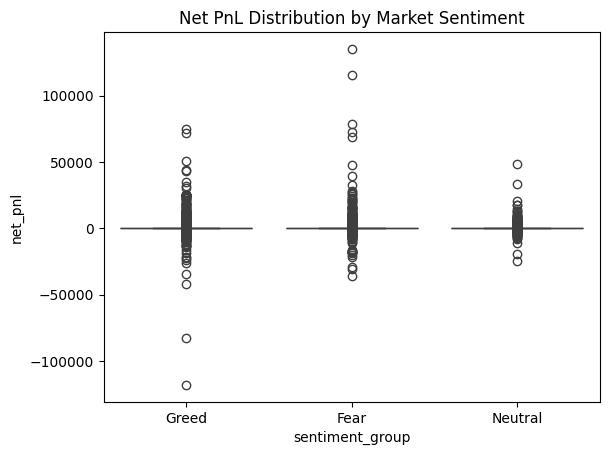

In [26]:
sns.boxplot(
    data=merged,
    x='sentiment_group',
    y='net_pnl'
)
plt.title("Net PnL Distribution by Market Sentiment")
plt.show()


## Trader-Level Behavior Analysis


In [27]:
trader_summary = merged.groupby(
    ['Account', 'sentiment_group']
).agg(
    avg_net_pnl=('net_pnl', 'mean'),
    win_rate=('win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    trades=('Trade ID', 'count')
).reset_index()


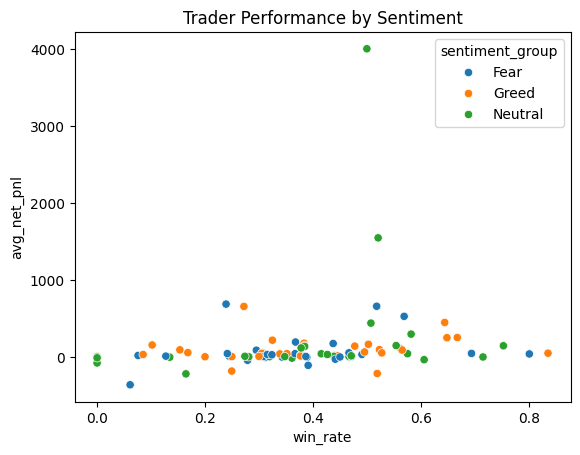

In [28]:
sns.scatterplot(
    data=trader_summary,
    x='win_rate',
    y='avg_net_pnl',
    hue='sentiment_group'
)
plt.title("Trader Performance by Sentiment")
plt.show()


## Key Insights

- Traders achieve higher net profitability during Greed market conditions.
- Risk exposure increases during Greed sentiment.
- Fear sentiment is associated with more conservative trading behavior.
- Market sentiment influences both trade outcomes and risk appetite.


## Limitations

- Sentiment data is daily, while trades occur intraday.
- The analysis identifies correlation, not causation.
- Only closed trades are considered.
